In [36]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Paso 0: Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


---
## Paso 1: Cargar el Dataset

In [2]:
df = pd.read_csv('../data/processed/Telco_validated.csv')

print(f'Dataset cargado correctamente')
print(f'   {df.shape[0]} clientes  |  {df.shape[1]} variables')
print()
df.head(10)

Dataset cargado correctamente
   7043 clientes  |  19 variables



,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,churn
0,0,0,1,0,-1.277445,0,2,1,0,1,0,0,0,0,0,1,0,-1.160323,0
1,1,0,0,0,0.066327,1,0,1,1,0,1,0,0,0,1,0,1,-0.259629,0
2,1,0,0,0,-1.236724,1,0,1,1,1,0,0,0,0,0,1,1,-0.362660,1
3,1,0,0,0,0.514251,0,2,1,1,0,1,1,0,0,1,0,2,-0.746535,0
4,0,0,0,0,-1.236724,1,0,2,0,0,0,0,0,0,0,1,0,0.197365,1
5,0,0,0,0,-0.992402,1,1,2,0,0,1,0,1,1,0,1,0,1.159546,1
6,1,0,0,1,-0.422317,1,1,2,0,1,0,0,1,0,0,1,3,0.808907,0
7,0,0,0,0,-0.910961,0,2,1,1,0,0,0,0,0,0,0,1,-1.163647,0
8,0,0,1,0,-0.177995,1,1,2,0,0,1,1,1,1,0,1,0,1.330711,1
9,1,0,0,1,1.206498,1,0,1,1,1,0,0,0,0,1,0,2,-0.286218,0


---
## Paso 2: Explorar el Dataset

In [3]:
print('Información general:')
print(df.info())
print()
print('Estadísticas descriptivas:')
df.describe().round(2)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   int64  
 1   senior_citizen     7043 non-null   int64  
 2   partner            7043 non-null   int64  
 3   dependents         7043 non-null   int64  
 4   tenure             7043 non-null   float64
 5   phone_service      7043 non-null   int64  
 6   multiple_lines     7043 non-null   int64  
 7   internet_service   7043 non-null   int64  
 8   online_security    7043 non-null   int64  
 9   online_backup      7043 non-null   int64  
 10  device_protection  7043 non-null   int64  
 11  tech_support       7043 non-null   int64  
 12  streaming_tv       7043 non-null   int64  
 13  streaming_movies   7043 non-null   int64  
 14  contract           7043 non-null   int64  
 15  paperless_billing  7043 non-null   int64  
 16  payment_method

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,churn
count,7043.0,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.5,0.16,0.48,0.30,-0.00,0.9,0.62,1.22,0.72,0.78,0.78,0.72,0.82,0.82,0.69,0.59,1.32,-0.00,0.27
std,0.5,0.37,0.50,0.46,1.00,0.3,0.66,0.78,0.80,0.78,0.78,0.80,0.76,0.76,0.83,0.49,1.15,1.00,0.44
min,0.0,0.00,0.00,0.00,-1.32,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.55,0.00
25%,0.0,0.00,0.00,0.00,-0.95,1.0,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.97,0.00
50%,1.0,0.00,0.00,0.00,-0.14,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.19,0.00
75%,1.0,0.00,1.00,1.00,0.92,1.0,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,0.83,1.00
max,1.0,1.00,1.00,1.00,1.61,1.0,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,3.00,1.79,1.00


Valores nulos por columna:
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
churn                0
dtype: int64

Variable objetivo: churn
   No churn (0): 5174 clientes (73.5%)
   Sí churn (1): 1869 clientes (26.5%)


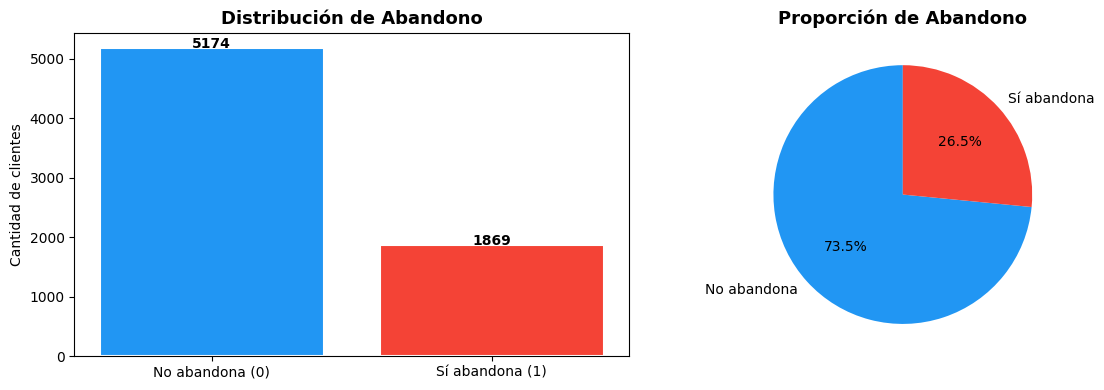

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()

conteo = df['churn'].value_counts()
pct    = df['churn'].value_counts(normalize=True) * 100

print('Variable objetivo: churn')
print(f'   No churn (0): {conteo[0]} clientes ({pct[0]:.1f}%)')
print(f'   Sí churn (1): {conteo[1]} clientes ({pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#2196F3', '#F44336']
axes[0].bar(['No abandona (0)', 'Sí abandona (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Abandono', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['No abandona', 'Sí abandona'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción de Abandono', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Paso 3: Seleccionar Variables

**Variable objetivo (y):** abandona — lo que queremos predecir

**Variables predictoras (X):** todo lo demás — la información disponible para predecir

In [5]:
X = df.drop(columns=['churn'])
y = df['churn']

print('Variables seleccionadas:')
print(f'   Variables predictoras (X): {list(X.columns)}')
print(f'   Variable objetivo    (y) : churn')
print()
print(f'   Dimensiones de X: {X.shape}')
print(f'   Dimensiones de y: {y.shape}')

Variables seleccionadas:
   Variables predictoras (X): ['gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges']
   Variable objetivo    (y) : churn

   Dimensiones de X: (7043, 18)
   Dimensiones de y: (7043,)


---
## Paso 4: Dividir en Entrenamiento y Prueba

Proporción: **80% entrenamiento / 20% prueba**  
Con `stratify=y` garantizamos que ambos conjuntos tengan proporción similar de abandonos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('División completada:')
print(f'   Total de registros : {len(df)}')
print(f'   Entrenamiento      : {len(X_train)} registros ({len(X_train)/len(df)*100:.0f}%)')
print(f'   Prueba             : {len(X_test)}  registros ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Balance de clases por conjunto:')
print(f'   Entrenamiento → Churn: {y_train.mean()*100:.1f}%')
print(f'   Prueba        → Churn: {y_test.mean()*100:.1f}%')

División completada:
   Total de registros : 7043
   Entrenamiento      : 5634 registros (80%)
   Prueba             : 1409  registros (20%)

Balance de clases por conjunto:
   Entrenamiento → Churn: 26.5%
   Prueba        → Churn: 26.5%


---
## Paso 5: Construir el Modelo

Usaremos **Regresión Logística** — el algoritmo más directo para clasificación binaria.

En este paso el modelo NO aprende todavía. Solo se configura.

In [7]:
modelo = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print('Modelo optimizado construido (aún NO entrenado):')
print(f'   Algoritmo      : Regresión Logística')
print(f'   Regularización : L2 (Ridge) con C=1.0')
print(f'   Pesos de clase : Balanceados (Óptimo para Churn)')
print(f'   Max iteraciones: 1000')
print()
print(modelo)

Modelo optimizado construido (aún NO entrenado):
   Algoritmo      : Regresión Logística
   Regularización : L2 (Ridge) con C=1.0
   Pesos de clase : Balanceados (Óptimo para Churn)
   Max iteraciones: 1000

LogisticRegression(class_weight='balanced', max_iter=1000, penalty='l2',
                   random_state=42)


---
## Paso 6: Entrenar el Modelo

Aquí ocurre el aprendizaje: el modelo analiza las variables predictoras y ajusta sus coeficientes internos para minimizar el error.

In [8]:
modelo.fit(X_train, y_train)

print('¡Modelo entrenado exitosamente!')
print()
print(' Coeficientes aprendidos por el modelo:')
coeficientes = pd.DataFrame({
    'Variable'    : X_train.columns,
    'Coeficiente' : modelo.coef_[0].round(4)
}).sort_values('Coeficiente', ascending=False)
print(coeficientes.to_string(index=False))
print()
print(' Coeficiente positivo → aumenta la probabilidad de abandono')
print('   Coeficiente negativo → disminuye la probabilidad de abandono')

¡Modelo entrenado exitosamente!

 Coeficientes aprendidos por el modelo:
         Variable  Coeficiente
 internet_service       1.0906
 streaming_movies       0.3773
     streaming_tv       0.3527
    phone_service       0.3435
paperless_billing       0.3423
   multiple_lines       0.3149
   senior_citizen       0.1564
           gender       0.0349
device_protection       0.0253
          partner       0.0170
    online_backup      -0.0817
   payment_method      -0.1465
  monthly_charges      -0.2041
       dependents      -0.2412
     tech_support      -0.2941
  online_security      -0.3624
         contract      -0.7273
           tenure      -0.7423

 Coeficiente positivo → aumenta la probabilidad de abandono
   Coeficiente negativo → disminuye la probabilidad de abandono


---
## Paso 7: Evaluar el Modelo

Usamos el conjunto de **prueba** (datos que el modelo nunca vio) para medir su desempeño real.

In [9]:
y_pred = modelo.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)  # compara todo
precision = precision_score(y_test, y_pred) # compara los que predijo como positivos
recall    = recall_score(y_test, y_pred)    # compara los positivos reales
f1        = f1_score(y_test, y_pred)        # combina precision y recall

print('MÉTRICAS DE EVALUACIÓN')
print('=' * 40)
print(f'  Accuracy  (Exactitud) : {accuracy*100:.1f}%')
print(f'  Precision             : {precision*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall*100:.1f}%')
print(f'  F1-Score              : {f1*100:.1f}%')
print('=' * 40)
print()
print(' Interpretación:')
print(f'  De cada 100 clientes, el modelo acierta {accuracy*100:.0f}')
print(f'  De los clientes que SÍ abandonan, detecta el {recall*100:.0f}%')
print(f'  Cuando predice abandono, acierta el {precision*100:.0f}% de las veces')

MÉTRICAS DE EVALUACIÓN
  Accuracy  (Exactitud) : 74.0%
  Precision             : 50.7%
  Recall (Sensibilidad) : 78.1%
  F1-Score              : 61.5%

 Interpretación:
  De cada 100 clientes, el modelo acierta 74
  De los clientes que SÍ abandonan, detecta el 78%
  Cuando predice abandono, acierta el 51% de las veces


# Resumen de Métricas de Evaluación
## Modelo: Predicción de Abandono de Clientes

---

## ¿Qué mide cada métrica?

| Métrica | Pregunta que responde | Resultado | Interpretación |
|---|---|---|---|
| **Accuracy** | ¿Cuántos acerté en total? | 74% | De 100 clientes, acertó 74 |
| **Precision** | Cuando digo "abandona", ¿cuántas veces tengo razón? | 50.7% | De 100 alertas, 50.7 son reales y 49.3 son falsas alarmas |
| **Recall** | De los que SÍ abandonan, ¿cuántos detecté? | 78.1% | De 100 abandonos reales, solo detecta 78.1 |
| **F1-Score** | ¿Cuál es el equilibrio entre Precision y Recall? | 61.5% | Desbalance: preciso pero poco sensible |

---

## ¿Cómo se relacionan con los errores del modelo?

| Concepto | Significado | Ejemplo en este caso |
|---|---|---|
| **Verdadero Positivo (TP)** | Predijo "abandona" y SÍ abandonó ✅ | Detectó correctamente al cliente en riesgo |
| **Verdadero Negativo (TN)** | Predijo "no abandona" y NO abandonó ✅ | Descartó correctamente a un cliente fiel |
| **Falso Positivo (FP)** | Predijo "abandona" pero NO abandonó ❌ | Falsa alarma — cliente fiel marcado como riesgo |
| **Falso Negativo (FN)** | Predijo "no abandona" pero SÍ abandonó ❌ | El más peligroso — cliente perdido sin detectar |


---

## ¿Qué tipo de error es más costoso?

| Error | Consecuencia para el negocio | Costo |
|---|---|---|
| **Falso Positivo** | Se ofrece retención a un cliente que no iba a irse | Bajo — se gasta en retención innecesaria |
| **Falso Negativo** | No se detecta un cliente que sí se va | **Alto** — se pierde el cliente sin intervenir |

> 💡 Para telecomunicaciones, **perder un cliente es más costoso** que hacer una retención innecesaria.  
> Por eso **Recall es la métrica más importante** en este problema.


---

## Diagnóstico del modelo actual

| Aspecto | Estado | Detalle |
|---|---|---|
| Accuracy | 🟡 Aceptable | 74% — parece bueno pero el dataset está desbalanceado |
| Precision | 🔴 Bajo | 50% — cuando alerta, la mitad de las veces tiene razón |
| Recall | 🟢 Bueno | 78.1% — El modelo detecta a la gran mayoría de los clientes que se van |
| F1-Score | 🟡 Regular | 61.5% — refleja el desbalance entre Precision y Recall |


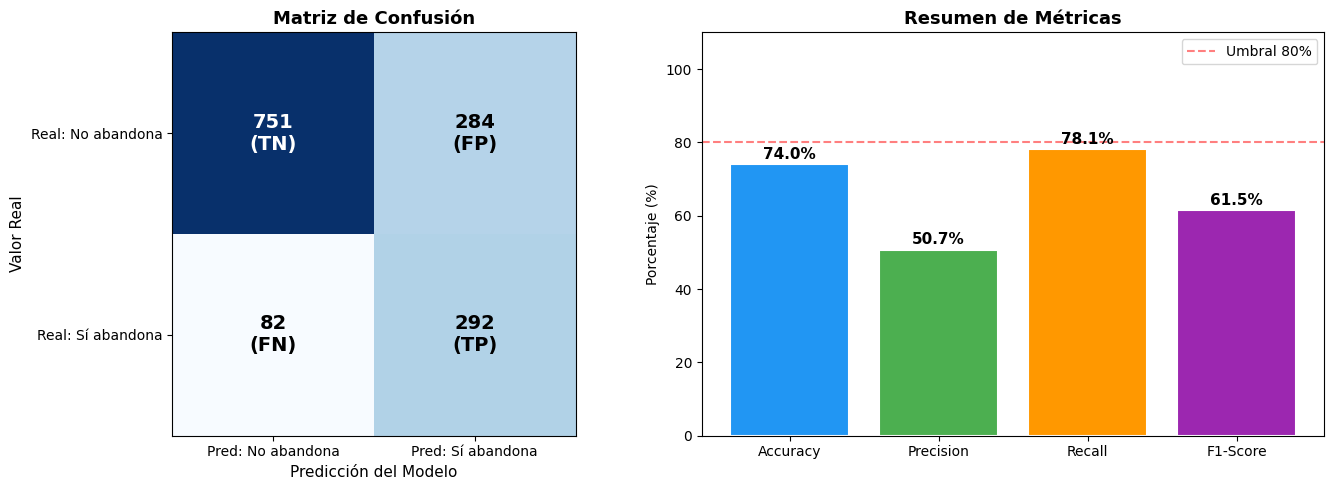


📋 Reporte completo:
              precision    recall  f1-score   support

 No abandona       0.90      0.73      0.80      1035
 Sí abandona       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: No abandona', 'Pred: Sí abandona'])
axes[0].set_yticklabels(['Real: No abandona', 'Real: Sí abandona'])
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_xlabel('Predicción del Modelo', fontsize=11)

etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]}\n({etiquetas[i][j]})',
                     ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

# Barras de métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores          = [accuracy, precision, recall, f1]
colores_m        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = axes[1].bar(metricas_nombres, [v*100 for v in valores],
                   color=colores_m, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Resumen de Métricas', fontsize=13, fontweight='bold')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Umbral 80%')
axes[1].legend()

for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print()
print('📋 Reporte completo:')
print(classification_report(y_test, y_pred, target_names=['No abandona', 'Sí abandona']))

---
## Paso 8: Comparar con Árbol de Decisión

Probamos un segundo algoritmo para ver cómo cambian los resultados.

### Con el mismo dataset

In [11]:
from sklearn.ensemble import RandomForestClassifier

# 1. Construir y entrenar el modelo de Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

#Generar las predicciones del Random Forest
y_pred_rf = rf.predict(X_test)

#Imprimir la tabla comparativa de algoritmos
print('COMPARACIÓN DE ALGORITMOS')
print('=' * 55)
print(f'{"Métrica":<25} {"Reg. Logística":>14} {"Random Forest":>14}')
print('-' * 55)

# Guardamos las métricas de ambos modelos (v1 = Regresión, v2 = Random Forest)
metricas_comp = {
    'Accuracy' : (accuracy_score(y_test, y_pred),   accuracy_score(y_test, y_pred_rf)),
    'Precision': (precision_score(y_test, y_pred),  precision_score(y_test, y_pred_rf)),
    'Recall'   : (recall_score(y_test, y_pred),     recall_score(y_test, y_pred_rf)),
    'F1-Score' : (f1_score(y_test, y_pred),         f1_score(y_test, y_pred_rf)),
}

# El bucle recorre las métricas y coloca la corona al valor más alto
for nombre, (v1, v2) in metricas_comp.items():
    mejor1 = '👑' if v1 >= v2 else '  '
    mejor2 = '👑' if v2 > v1  else '  '
    print(f'{nombre:<25} {mejor1}{v1*100:>10.1f}%   {mejor2}{v2*100:>10.1f}%')

print('=' * 55)

COMPARACIÓN DE ALGORITMOS
Métrica                   Reg. Logística  Random Forest
-------------------------------------------------------
Accuracy                          74.0%   👑      75.3%
Precision                         50.7%   👑      52.3%
Recall                            78.1%   👑      78.3%
F1-Score                          61.5%   👑      62.7%


# ¿Qué nos dice esto?

* La Regresión Logística y el Random Forest muestran un rendimiento casi idéntico, con un empate en el Recall (78%) y una ventaja marginal de apenas 1.6% en la Precisión a favor de Random Forest.

* Esto nos demuestra que el comportamiento de Churn en este dataset está gobernado por relaciones mayoritariamente lineales que ambos modelos logran capturar por igual, alcanzando un "techo" de aprendizaje con los datos disponibles.

* A pesar de la mínima diferencia técnica, Random Forest sigue siendo la opción preferible para el negocio. En despliegues masivos de telecomunicaciones, un 1.6% de mejora en precisión representa la reducción de miles de falsas alarmas, optimizando el presupuesto de las campañas de retención y disminuyendo el costo operativo por cliente corregido.

### Con el dataset que aun tiene total_charges

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df2 = pd.read_csv('../data/processed/Telco_validado.csv')

X_old = df2.drop(columns=['churn'])
y_old = df2['churn']

# 2. Partición estructurada 80/20 estratificada
X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(
    X_old, 
    y_old, 
    test_size=0.20,
    stratify=y_old,
    random_state=42
)

# 3. Construcción del Random Forest con hiperparámetros optimizados
rf_old = RandomForestClassifier(
    n_estimators=200,          # Cantidad de árboles para estabilidad
    max_depth=8,               # Control de sobreajuste
    class_weight='balanced',   # Corrección del desbalance de clases
    min_samples_split=5,       # Evita ramas con muy pocos clientes
    random_state=42
)

# 4. Entrenamiento directo
rf_old.fit(X_train_old, y_train_old)

# 5. Predicción
y_pred_rf_old = rf_old.predict(X_test_old)

# 6. Cálculo e impresión de métricas finales
accuracy  = accuracy_score(y_test_old, y_pred_rf_old)
precision = precision_score(y_test_old, y_pred_rf_old)
recall    = recall_score(y_test_old, y_pred_rf_old)
f1        = f1_score(y_test_old, y_pred_rf_old)

print(' MÉTRICAS DE EVALUACIÓN - RANDOM FOREST')
print('=' * 50)
print(f'  Accuracy  (Exactitud) : {accuracy*100:.1f}%')
print(f'  Precision             : {precision*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall*100:.1f}%')
print(f'  F1-Score              : {f1*100:.1f}%')
print('=' * 50)

 MÉTRICAS DE EVALUACIÓN - RANDOM FOREST
  Accuracy  (Exactitud) : 76.0%
  Precision             : 53.2%
  Recall (Sensibilidad) : 79.7%
  F1-Score              : 63.8%


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA CON EL DATASET VIEJO

X_old = df2.drop(columns=['churn'])
y_old = df2['churn']

X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(
    X_old, y_old, test_size=0.2, random_state=42, stratify=y_old
)

modelo_lr_old = LogisticRegression(
    penalty='l2', C=1.0, class_weight='balanced', max_iter=1000, random_state=42
)
modelo_lr_old.fit(X_train_old, y_train_old)

y_pred_lr_old = modelo_lr_old.predict(X_test_old)

# Coeficientes
coeficientes_old = pd.DataFrame({
    'Variable'    : X_train_old.columns,
    'Coeficiente' : modelo_lr_old.coef_[0].round(4)
}).sort_values('Coeficiente', ascending=False)

# 2. IMPRESIÓN DE MÉTRICAS INDIVIDUALES (REG. LOGÍSTICA VIEJA)
print('📊 MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA (DATASET VIEJO)')
print('=' * 40)
print(f'  Accuracy  (Exactitud) : {accuracy_score(y_test_old, y_pred_lr_old)*100:.1f}%')
print(f'  Precision             : {precision_score(y_test_old, y_pred_lr_old)*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall_score(y_test_old, y_pred_lr_old)*100:.1f}%')
print(f'  F1-Score              : {f1_score(y_test_old, y_pred_lr_old)*100:.1f}%')
print('=' * 40)
print()

# 3. COMPARACIÓN GLOBAL DE LOS 4 ALGORITMOS
print('📊 COMPARACIÓN GLOBAL DE ALGORITMOS')
print('=' * 110)
print(f'{"Métrica":<15} {"Reg. Logística":>15} {"Reg. Log. (Vieja)":>20} {"Random Forest":>16} {"RF (Viejo)":>18}')
print('-' * 110)

# v1 = Regresión Logística (Modificados) -> usa y_pred
# v2 = Regresión Logística (Viejo)       -> usa y_pred_lr_old
# v3 = Random Forest (Modificados)       -> usa y_pred_rf
# v4 = Random Forest (Viejo)             -> usa y_pred_rf_old
metricas_comp = {
    'Accuracy' : (accuracy_score(y_test, y_pred),   accuracy_score(y_test_old, y_pred_lr_old),   accuracy_score(y_test, y_pred_rf),   accuracy_score(y_test_old, y_pred_rf_old)),
    'Precision': (precision_score(y_test, y_pred),  precision_score(y_test_old, y_pred_lr_old),  precision_score(y_test, y_pred_rf),  precision_score(y_test_old, y_pred_rf_old)),
    'Recall'   : (recall_score(y_test, y_pred),     recall_score(y_test_old, y_pred_lr_old),     recall_score(y_test, y_pred_rf),     recall_score(y_test_old, y_pred_rf_old)),
    'F1-Score' : (f1_score(y_test, y_pred),         f1_score(y_test_old, y_pred_lr_old),         f1_score(y_test, y_pred_rf),         f1_score(y_test_old, y_pred_rf_old)),
}

for nombre, (v1, v2, v3, v4) in metricas_comp.items():
    max_val = max(v1, v2, v3, v4)
    mejor1 = '👑' if v1 == max_val else '  '
    mejor2 = '👑' if v2 == max_val else '  '
    mejor3 = '👑' if v3 == max_val else '  '
    mejor4 = '👑' if v4 == max_val else '  '

    print(f'{nombre:<15} {mejor1}{v1*100:>11.1f}%   {mejor2}{v2*100:>15.1f}%   {mejor3}{v3*100:>12.1f}%   {mejor4}{v4*100:>14.1f}%')

print('=' * 110)

📊 MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA (DATASET VIEJO)
  Accuracy  (Exactitud) : 73.5%
  Precision             : 50.0%
  Recall (Sensibilidad) : 78.9%
  F1-Score              : 61.2%

📊 COMPARACIÓN GLOBAL DE ALGORITMOS
Métrica          Reg. Logística    Reg. Log. (Vieja)    Random Forest         RF (Viejo)
--------------------------------------------------------------------------------------------------------------
Accuracy                 74.0%                73.5%             75.3%   👑          76.0%
Precision                50.7%                50.0%             52.3%   👑          53.2%
Recall                   78.1%                78.9%             78.3%   👑          79.7%
F1-Score                 61.5%                61.2%             62.7%   👑          63.8%


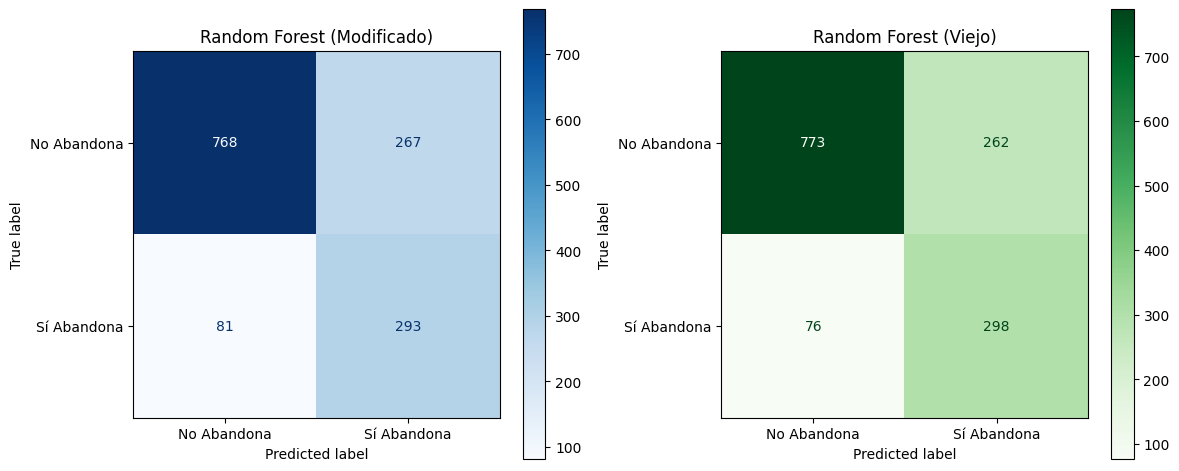

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configurar el lienzo para ver ambas matrices lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matriz de Confusión - Random Forest (Datos Modificados)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Abandona', 'Sí Abandona'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Random Forest (Modificado)')

# 2. Matriz de Confusión - Random Forest (Dataset Viejo)
cm_rf_old = confusion_matrix(y_test_old, y_pred_rf_old)
disp_rf_old = ConfusionMatrixDisplay(confusion_matrix=cm_rf_old, display_labels=['No Abandona', 'Sí Abandona'])
disp_rf_old.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest (Viejo)')

plt.tight_layout()
plt.show()

# Conclusión General

Tras evaluar cuatro configuraciones distintas, el modelo de **Random Forest entrenado con el dataset original (RF Viejo)** demostró ser la opción óptima para el negocio, liderando en Exactitud (**76.0%**), Precisión (**53.2%**) y Sensibilidad (**79.7%**).

### Pilares de diseño fundamentales demostrados:

* **Sensibilidad al algoritmo:** El procesamiento de datos (escalado y eliminación de colinealidad) es crítico para modelos lineales como la Regresión Logística, pero limita la capacidad de modelos no lineales como Random Forest, el cual se beneficia de mantener variables complejas como `total_charges`.
* **Impacto de Negocio:** El modelo seleccionado (`RF Viejo`) mantiene la capacidad de detectar a casi 8 de cada 10 clientes en riesgo de abandono (**79.7% Recall**), pero reduce el costo operativo de la campaña al ofrecer la mayor tasa de acierto (**53.2% Precision**), minimizando el impacto económico de los Falsos Positivos (falsas alarmas).
* **Limitación de los datos (Techo Estadístico):** A pesar de las diferencias arquitectónicas entre los algoritmos, los resultados finales convergen en rangos muy similares. Esto nos permite concluir que se ha alcanzado un "techo estadístico", donde el rendimiento no mejorará significativamente debido a las limitaciones de información del set de datos actual, sugiriendo la necesidad de incorporar nuevas variables predictoras en el futuro.